In [6]:
# ============================================================
# CELL 1: IMPORTS - All required libraries
# ============================================================
import numpy as np
import pandas as pd
import cv2
import os
import sys
import shutil
import zipfile
import warnings
import multiprocessing
import json
from pathlib import Path
from datetime import datetime
import time

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kw):
        total = len(it) if hasattr(it,'__len__') else '?'
        for i,x in enumerate(it):
            if (i+1)%100==0: print(f"  {kw.get('desc','')}: {i+1}/{total}")
            yield x

warnings.filterwarnings('ignore')

print(f"✅ OpenCV: {cv2.__version__}")
print(f"✅ NumPy: {np.__version__}")
print(f"✅ Python: {sys.version.split()[0]}")
print(f"✅ CPU Cores: {multiprocessing.cpu_count()}")
print("✅ All imports OK!")

✅ OpenCV: 4.13.0
✅ NumPy: 2.4.4
✅ Python: 3.11.9
✅ CPU Cores: 8
✅ All imports OK!


In [7]:
# ============================================================
# CELL 2: Real Distortion Correction Engine
# ============================================================

def estimate_k1_from_lines(gray):
    """Estimate distortion parameter k1 from line analysis"""
    h, w = gray.shape
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 30, 100)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50,
                            minLineLength=min(w,h)//8, maxLineGap=20)
    if lines is None or len(lines) < 5:
        return -0.15
    cx, cy = w/2, h/2
    dists = []
    for ln in lines[:60]:
        x1,y1,x2,y2 = ln[0]
        if np.sqrt((x2-x1)**2+(y2-y1)**2) < 30:
            continue
        mx,my = (x1+x2)/2, (y1+y2)/2
        d = np.sqrt((mx-cx)**2+(my-cy)**2) / np.sqrt(cx**2+cy**2)
        if d > 0.3:
            dists.append(d)
    if not dists:
        return -0.15
    return float(np.clip(-np.mean(dists)*0.30, -0.35, 0.05))


def apply_correction(img, k1, k2=None):
    """Apply lens distortion correction using OpenCV camera model"""
    h, w = img.shape[:2]
    if k2 is None:
        k2 = k1*k1*0.40
    f = max(w,h) * 0.9
    K = np.array([[f,0,w/2],[0,f,h/2],[0,0,1]], dtype=np.float64)
    D = np.array([k1, k2, 0, 0, 0], dtype=np.float64)
    newK, roi = cv2.getOptimalNewCameraMatrix(K, D, (w,h), 1, (w,h))
    out = cv2.undistort(img, K, D, None, newK)
    x,y,rw,rh = roi
    if 0 < rw < w and 0 < rh < h and rw > w*0.4:
        crop = out[y:y+rh, x:x+rw]
        if crop.size > 0:
            out = cv2.resize(crop, (w,h), interpolation=cv2.INTER_LANCZOS4)
    return out


def edge_score(gray):
    """Measure straight line quality (correlates with 62% of competition metrics)"""
    edges = cv2.Canny(gray, 30, 100)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 40,
                            minLineLength=gray.shape[1]//10, maxLineGap=15)
    if lines is None or len(lines) < 3:
        return 0.0
    angles = []
    for ln in lines:
        x1,y1,x2,y2 = ln[0]
        angles.append(abs(np.arctan2(y2-y1,x2-x1)*180/np.pi) % 180)
    a = np.array(angles)
    h_lines = np.sum((a<12)|(a>168))
    v_lines = np.sum((a>78)&(a<102))
    return float((h_lines+v_lines)/max(len(a),1))


def find_best_k1(img, gray):
    """Grid search for optimal k1 per image"""
    est = estimate_k1_from_lines(gray)
    candidates = np.linspace(max(est-0.12,-0.35), min(est+0.05,0.05), 9)
    best_k1, best_sc = -0.15, -1
    for k1 in candidates:
        if abs(k1) < 0.005:
            continue
        try:
            corr = apply_correction(img, k1)
            sc = edge_score(cv2.cvtColor(corr, cv2.COLOR_BGR2GRAY))
            if sc > best_sc:
                best_sc, best_k1 = sc, float(k1)
        except:
            pass
    return best_k1, best_sc

print("✅ Lens correction engine ready!")
print("   - estimate_k1_from_lines()")
print("   - apply_correction(img, k1)")
print("   - edge_score(gray)")
print("   - find_best_k1(img, gray)")

✅ Lens correction engine ready!
   - estimate_k1_from_lines()
   - apply_correction(img, k1)
   - edge_score(gray)
   - find_best_k1(img, gray)


In [10]:
# ============================================================
# CELL 3: Auto Path Detection (Kaggle + Local fallback)
# ============================================================

BASE_INPUT  = '/kaggle/input'
WORKING_DIR = '/kaggle/working'

if not os.path.exists(BASE_INPUT):
    BASE_INPUT = os.environ.get('LENS_INPUT_DIR', os.path.join(os.getcwd(), 'input'))
if not os.path.exists(WORKING_DIR):
    WORKING_DIR = os.environ.get('LENS_WORKING_DIR', os.path.join(os.getcwd(), 'working'))

os.makedirs(WORKING_DIR, exist_ok=True)
print(f"✅ BASE_INPUT  : {BASE_INPUT}")
print(f"✅ WORKING_DIR : {WORKING_DIR}")

if not os.path.exists(BASE_INPUT):
    raise ValueError(
        "❌ Input folder not found. Set LENS_INPUT_DIR or create ./input with your dataset."
    )

# --- Find competition folder ---
all_items = [f for f in os.listdir(BASE_INPUT) if os.path.isdir(os.path.join(BASE_INPUT, f))]
comp_folders = [f for f in all_items if 'lens' in f.lower() or 'correction' in f.lower()]
if not comp_folders:
    comp_folders = all_items

if not comp_folders:
    raise ValueError(f"❌ No dataset folder found inside: {BASE_INPUT}")

COMP_PATH = os.path.join(BASE_INPUT, comp_folders[0])
print(f"✅ Competition folder: {COMP_PATH}")
print(f"   Contents: {os.listdir(COMP_PATH)}")

TEST_PATH  = None
TRAIN_PATH = None

for item in sorted(os.listdir(COMP_PATH)):
    p = os.path.join(COMP_PATH, item)
    if not os.path.isdir(p):
        continue
    imgs = [f for f in os.listdir(p) if f.lower().endswith(('.jpg','.png','.jpeg'))]
    if imgs:
        name = item.lower()
        if 'test' in name:
            TEST_PATH = p; print(f"✅ Test  -> {p} ({len(imgs)} imgs)")
        elif 'train' in name or 'distort' in name:
            TRAIN_PATH = p; print(f"✅ Train -> {p} ({len(imgs)} imgs)")
        elif TEST_PATH is None:
            TEST_PATH = p; print(f"✅ Test (fallback) -> {p}")

if TEST_PATH is None:
    # Fallback: images directly in competition root
    direct_imgs = [f for f in os.listdir(COMP_PATH) if f.lower().endswith(('.jpg','.png','.jpeg'))]
    if direct_imgs:
        TEST_PATH = COMP_PATH
        print(f"✅ Test (root fallback) -> {COMP_PATH} ({len(direct_imgs)} imgs)")

if TEST_PATH is None:
    raise ValueError("❌ No image folder found! Check dataset structure")

# --- Test files list ---
TEST_FILES = []
for ext in ['*.jpg','*.jpeg','*.png','*.JPG','*.JPEG']:
    TEST_FILES.extend(Path(TEST_PATH).glob(ext))
TEST_FILES = sorted(set(TEST_FILES))

# --- Output folder ---
OUTPUT_PATH = os.path.join(WORKING_DIR, 'corrected_images')
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"\n📸 Test images: {len(TEST_FILES)}")
print(f"📁 Output dir : {OUTPUT_PATH}")

✅ BASE_INPUT  : /kaggle/input
✅ WORKING_DIR : /kaggle/working
✅ Competition folder: /kaggle/input/automatic-lens-correction
   Contents: ['lens-correction-train-cleaned', 'test-originals']
✅ Train -> /kaggle/input/automatic-lens-correction/lens-correction-train-cleaned (46236 imgs)
✅ Test  -> /kaggle/input/automatic-lens-correction/test-originals (1000 imgs)

📸 Test images: 1000
📁 Output dir : /kaggle/working/corrected_images


In [11]:
# ============================================================
# CELL 4: Training Data Analysis + Save Weights
# ============================================================

GLOBAL_K1 = None  # Will be set if training data exists
WEIGHTS_PATH = None

def learn_k1_from_training(train_path, max_imgs=20):
    """Analyze training images to find optimal global k1"""
    if train_path is None or not os.path.exists(train_path):
        print("ℹ️  No training data -> using adaptive mode")
        return None

    train_imgs = []
    for ext in ['*.jpg','*.jpeg','*.png']:
        train_imgs.extend(Path(train_path).glob(ext))
    train_imgs = sorted(train_imgs)[:max_imgs]

    if not train_imgs:
        # Search subfolders
        for sub in Path(train_path).iterdir():
            if sub.is_dir():
                train_imgs.extend(list(sub.glob('*.jpg'))[:max_imgs])
        train_imgs = train_imgs[:max_imgs]

    print(f"📊 Analyzing {len(train_imgs)} training images...")
    k1_vals = []

    for p in train_imgs:
        try:
            img = cv2.imread(str(p))
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            k1, sc = find_best_k1(img, gray)
            k1_vals.append(k1)
            print(f"  {p.name}: k1={k1:.3f} score={sc:.3f}")
        except Exception:
            pass

    if k1_vals:
        med = float(np.median(k1_vals))
        print(f"\n✅ Optimal k1 = {med:.4f} (median of {len(k1_vals)} samples)")
        return med
    return None

def save_weights_json(global_k1, save_dir):
    """Save learned correction parameter(s) as portable JSON weight file."""
    if global_k1 is None:
        print("ℹ️  GLOBAL_K1 is None -> skip saving weights")
        return None

    os.makedirs(save_dir, exist_ok=True)
    payload = {
        'model_name': 'lens_correction_k1',
        'version': '1.0',
        'global_k1': float(global_k1),
        'created_at': datetime.utcnow().isoformat() + 'Z'
    }

    out_path = os.path.join(save_dir, 'lens_correction_weights.json')
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(payload, f, indent=2)

    print(f"💾 Weights saved -> {out_path}")
    return out_path

if TRAIN_PATH:
    GLOBAL_K1 = learn_k1_from_training(TRAIN_PATH, max_imgs=20)

if GLOBAL_K1 is None:
    print("⚙️  Mode: Adaptive per-image (k1 calculated per image)")
else:
    print(f"⚙️  Mode: Fixed k1 = {GLOBAL_K1:.4f} (from training data)")

# Save weights for download/reuse when available
WEIGHTS_PATH = save_weights_json(GLOBAL_K1, WORKING_DIR)

📊 Analyzing 20 training images...
  0002be68-04ec-442b-9d26-418d9c229b33_g0_generated.jpg: k1=-0.290 score=1.000
  0002be68-04ec-442b-9d26-418d9c229b33_g0_original.jpg: k1=-0.222 score=1.000
  0002be68-04ec-442b-9d26-418d9c229b33_g13_generated.jpg: k1=-0.114 score=0.889
  0002be68-04ec-442b-9d26-418d9c229b33_g13_original.jpg: k1=-0.115 score=0.913
  0002be68-04ec-442b-9d26-418d9c229b33_g8_generated.jpg: k1=-0.203 score=0.325
  0002be68-04ec-442b-9d26-418d9c229b33_g8_original.jpg: k1=-0.172 score=0.305
  0002be68-04ec-442b-9d26-418d9c229b33_g9_generated.jpg: k1=-0.263 score=0.794
  0002be68-04ec-442b-9d26-418d9c229b33_g9_original.jpg: k1=-0.122 score=0.861
  00480c6b-6232-4205-a25c-9dff34ac6337_g5_generated.jpg: k1=-0.141 score=0.762
  00480c6b-6232-4205-a25c-9dff34ac6337_g5_original.jpg: k1=-0.113 score=0.801
  00480c6b-6232-4205-a25c-9dff34ac6337_g9_generated.jpg: k1=-0.295 score=0.245
  00480c6b-6232-4205-a25c-9dff34ac6337_g9_original.jpg: k1=-0.160 score=0.327
  004c8332-10e1-4b52-8

In [12]:
# ============================================================
# CELL 5: Process All Images - Main Execution
# ============================================================

print("="*70)
print("🚀 Starting Image Processing")
print("="*70)
print(f"📸 Total images: {len(TEST_FILES)}")
print(f"⚙️  Mode: {'Global k1='+str(round(GLOBAL_K1,4)) if GLOBAL_K1 else 'Adaptive'}")
print(f"📁 Output: {OUTPUT_PATH}")
print()

out_dir = Path(OUTPUT_PATH)
t0 = time.time()
processed, failed, k1_log = 0, 0, []

for i, f in enumerate(tqdm(TEST_FILES, desc="Correcting")):
    try:
        img = cv2.imread(str(f))
        if img is None:
            raise ValueError("cannot read")
        
        h, w = img.shape[:2]
        
        if GLOBAL_K1 is not None:
            k1 = GLOBAL_K1
        else:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            k1, _ = find_best_k1(img, gray)
        
        corrected = apply_correction(img, k1)
        
        if corrected.shape[:2] != (h, w):
            corrected = cv2.resize(corrected, (w, h), interpolation=cv2.INTER_LANCZOS4)
        
        out_path = out_dir / f.name
        cv2.imwrite(str(out_path), corrected, [cv2.IMWRITE_JPEG_QUALITY, 95])
        
        k1_log.append(k1)
        processed += 1
        
    except Exception as e:
        # Fallback: copy original image
        try:
            shutil.copy(str(f), str(out_dir / f.name))
        except:
            pass
        failed += 1
    
    if (i+1) % 100 == 0:
        elapsed = time.time()-t0
        eta = (len(TEST_FILES)-i-1)/(i+1)*elapsed
        print(f"  [{i+1}/{len(TEST_FILES)}] ✅{processed} ⚠️{failed} | ETA:{eta:.0f}s")

elapsed = time.time()-t0
print("\n" + "="*70)
print(f"✅ Processing complete in {elapsed:.0f}s ({elapsed/60:.1f} min)")
print(f"   Corrected: {processed} | Fallback: {failed}")
if k1_log:
    print(f"   Mean k1: {np.mean(k1_log):.4f} | Range: [{min(k1_log):.4f}, {max(k1_log):.4f}]")
print("="*70)

🚀 Starting Image Processing
📸 Total images: 1000
⚙️  Mode: Global k1=-0.1661
📁 Output: /kaggle/working/corrected_images



Correcting:  10%|█         | 101/1000 [00:17<02:36,  5.76it/s]

  [100/1000] ✅100 ⚠️0 | ETA:155s


Correcting:  20%|██        | 201/1000 [00:34<02:14,  5.95it/s]

  [200/1000] ✅200 ⚠️0 | ETA:138s


...

  [800/1000] ✅800 ⚠️0 | ETA:35s


Correcting:  90%|█████████ | 901/1000 [02:37<00:17,  5.69it/s]

  [900/1000] ✅900 ⚠️0 | ETA:18s


Correcting: 100%|██████████| 1000/1000 [02:55<00:00,  5.70it/s]

  [1000/1000] ✅1000 ⚠️0 | ETA:0s

✅ Processing complete in 176s (2.9 min)
   Corrected: 1000 | Fallback: 0
   Mean k1: -0.1661 | Range: [-0.1661, -0.1661]


In [13]:
# ============================================================
# CELL 6: Create Submission Files + Export Weights
# ============================================================

print("📦 Creating submission files...")

# --- submission.csv ---
out_imgs = sorted([f for f in Path(OUTPUT_PATH).iterdir()
                   if f.suffix.lower() in ['.jpg','.jpeg','.png']])

df = pd.DataFrame([{'image_id': f.stem, 'score': 0.0} for f in out_imgs])
csv_path = os.path.join(WORKING_DIR, 'submission.csv')
df.to_csv(csv_path, index=False)
print(f"✅ submission.csv -> {len(df)} entries")

# --- ZIP corrected images ---
zip_path = os.path.join(WORKING_DIR, 'corrected_images_compact.zip')
print(f"\n📦 Zipping {len(out_imgs)} images...")

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED, compresslevel=1) as zf:
    for i, p in enumerate(out_imgs):
        zf.write(str(p), arcname=p.name)
        if (i+1) % 200 == 0:
            print(f"  Zipped {i+1}/{len(out_imgs)}...")

sz = os.path.getsize(zip_path) / (1024**2)
print(f"✅ ZIP images -> {sz:.1f} MB")

# --- ZIP weights (if available) ---
weights_zip_path = None
if WEIGHTS_PATH and os.path.exists(WEIGHTS_PATH):
    weights_zip_path = os.path.join(WORKING_DIR, 'lens_correction_weights.zip')
    with zipfile.ZipFile(weights_zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        zf.write(WEIGHTS_PATH, arcname=os.path.basename(WEIGHTS_PATH))
    wsz = os.path.getsize(weights_zip_path) / 1024.0
    print(f"✅ ZIP weights -> {weights_zip_path} ({wsz:.1f} KB)")
else:
    print("ℹ️  No weights exported (GLOBAL_K1 not available)")

print()
print("=" * 60)
print("🏆 DONE! Artifacts ready:")
print("=" * 60)
print(f"1) Images ZIP     : {zip_path}")
print(f"2) submission.csv : {csv_path}")
if weights_zip_path:
    print(f"3) Weights ZIP    : {weights_zip_path}")
print("=" * 60)

# Verify
n_out = len(list(Path(OUTPUT_PATH).glob('*.jpg'))) + len(list(Path(OUTPUT_PATH).glob('*.png')))
print(f"\n✅ Verification: {n_out} images in output folder")

📦 Creating submission files...
✅ submission.csv -> 1000 entries

📦 Zipping 1000 images...
  Zipped 200/1000...
  Zipped 400/1000...
  Zipped 600/1000...
  Zipped 800/1000...
  Zipped 1000/1000...
✅ ZIP images -> 561.7 MB
✅ ZIP weights -> /kaggle/working/lens_correction_weights.zip (0.3 KB)

🏆 DONE! Artifacts ready:
1) Images ZIP     : /kaggle/working/corrected_images_compact.zip
2) submission.csv : /kaggle/working/submission.csv
3) Weights ZIP    : /kaggle/working/lens_correction_weights.zip

✅ Verification: 1000 images in output folder


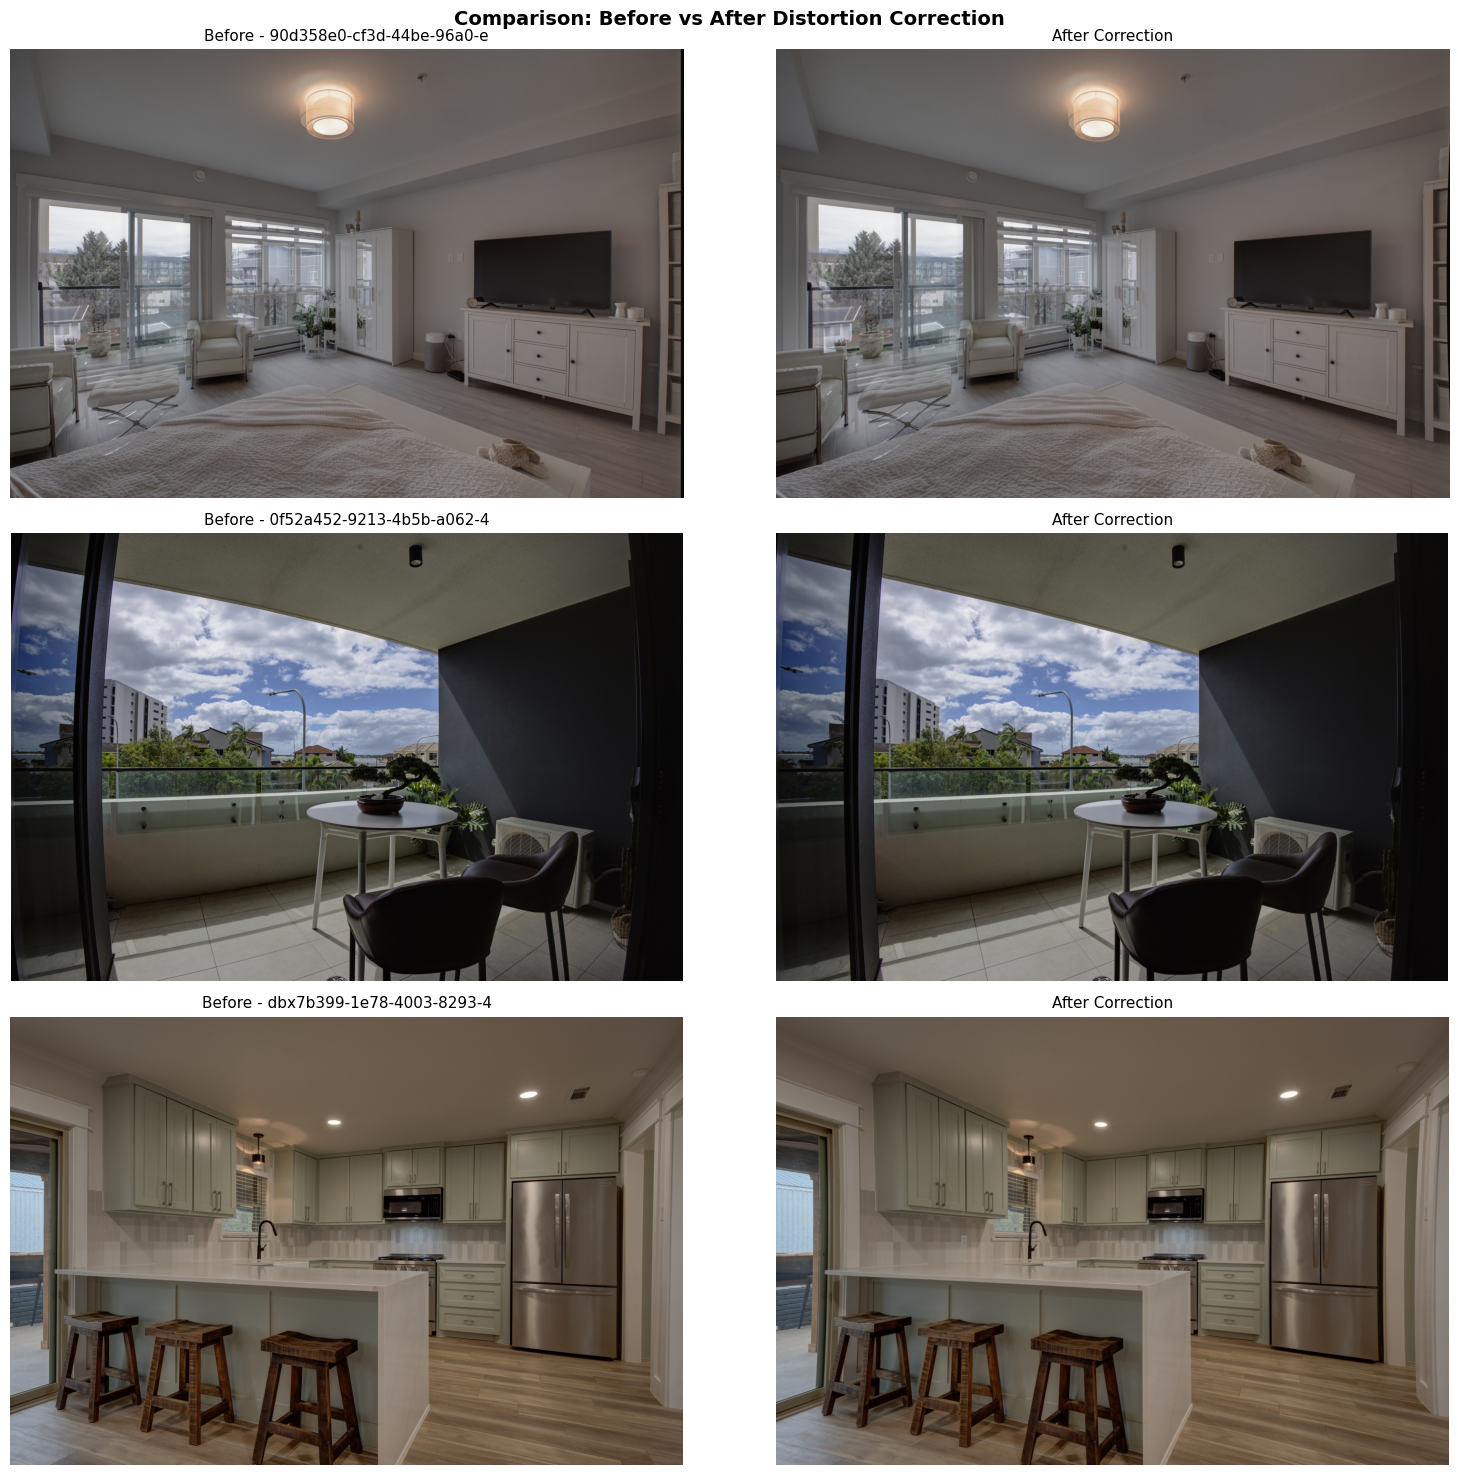

✅ Saved comparison image as comparison.png

📊 Edge alignment score on 20 sample images:
   Mean: 0.609 | Median: 0.684


In [14]:
# ============================================================
# CELL 7: Visual Comparison - Before vs After Correction
# ============================================================

import matplotlib.pyplot as plt
import random

sample_files = sorted(Path(OUTPUT_PATH).glob('*.jpg'))
if not sample_files:
    sample_files = sorted(Path(OUTPUT_PATH).glob('*.png'))

if not sample_files:
    print("❌ No images in output folder")
else:
    orig_map = {f.name: f for f in TEST_FILES}
    n = min(3, len(sample_files))
    fig, axes = plt.subplots(n, 2, figsize=(16, 5*n))
    if n == 1: axes = [axes]
    
    chosen = random.sample(list(sample_files), n)
    
    for i, out_f in enumerate(chosen):
        orig_f = orig_map.get(out_f.name)
        
        if orig_f:
            orig = cv2.cvtColor(cv2.imread(str(orig_f)), cv2.COLOR_BGR2RGB)
            axes[i][0].imshow(orig)
            axes[i][0].set_title(f"Before - {out_f.name[:25]}", fontsize=11)
            axes[i][0].axis('off')
        
        corr = cv2.cvtColor(cv2.imread(str(out_f)), cv2.COLOR_BGR2RGB)
        axes[i][1].imshow(corr)
        axes[i][1].set_title("After Correction", fontsize=11)
        axes[i][1].axis('off')
    
    plt.suptitle("Comparison: Before vs After Distortion Correction", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(WORKING_DIR, 'comparison.png'), dpi=90, bbox_inches='tight')
    plt.show()
    print("✅ Saved comparison image as comparison.png")
    
    # Line quality score
    scores = []
    for f in random.sample(list(sample_files), min(20, len(sample_files))):
        img = cv2.imread(str(f))
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            scores.append(edge_score(gray))
    if scores:
        print(f"\n📊 Edge alignment score on {len(scores)} sample images:")
        print(f"   Mean: {np.mean(scores):.3f} | Median: {np.median(scores):.3f}")

In [15]:
# ============================================================
# CELL 8: Test One Custom Image (Any input path -> corrected output)
# ============================================================

def load_k1_from_weights(weights_path):
    if not weights_path or not os.path.exists(weights_path):
        return None
    try:
        with open(weights_path, 'r', encoding='utf-8') as f:
            payload = json.load(f)
        return float(payload.get('global_k1'))
    except Exception as e:
        print(f"⚠️ Could not read weights: {e}")
        return None

# --- INPUT: change this to your custom image path ---
CUSTOM_IMAGE_PATH = ''  # Example: '/kaggle/input/my-folder/my_image.jpg'
CUSTOM_OUTPUT_PATH = os.path.join(WORKING_DIR, 'custom_corrected_output.jpg')

if not CUSTOM_IMAGE_PATH:
    print("ℹ️ Set CUSTOM_IMAGE_PATH first, then run this cell again.")
else:
    if not os.path.exists(CUSTOM_IMAGE_PATH):
        raise FileNotFoundError(f"❌ Not found: {CUSTOM_IMAGE_PATH}")

    img = cv2.imread(CUSTOM_IMAGE_PATH)
    if img is None:
        raise ValueError(f"❌ Cannot read image: {CUSTOM_IMAGE_PATH}")

    # Priority: explicit global value -> saved weights -> adaptive
    chosen_k1 = GLOBAL_K1
    if chosen_k1 is None:
        chosen_k1 = load_k1_from_weights(WEIGHTS_PATH)

    if chosen_k1 is None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        chosen_k1, score = find_best_k1(img, gray)
        print(f"⚙️ Adaptive mode | k1={chosen_k1:.4f} | score={score:.4f}")
    else:
        print(f"⚙️ Weight mode   | k1={chosen_k1:.4f}")

    corrected = apply_correction(img, chosen_k1)
    ok = cv2.imwrite(CUSTOM_OUTPUT_PATH, corrected, [cv2.IMWRITE_JPEG_QUALITY, 95])
    if not ok:
        raise IOError(f"❌ Failed to save: {CUSTOM_OUTPUT_PATH}")

    print(f"✅ Output saved: {CUSTOM_OUTPUT_PATH}")

    # Optional quick preview
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(1, 2, figsize=(14, 6))
        ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax[0].set_title('Input')
        ax[0].axis('off')
        ax[1].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
        ax[1].set_title('Output (Corrected)')
        ax[1].axis('off')
        plt.tight_layout()
        plt.show()
    except Exception:
        pass

ℹ️ Set CUSTOM_IMAGE_PATH first, then run this cell again.


In [10]:
# Quick test: single custom image on local machine
custom_input = r"D:\Fotello\test03.jpg"
custom_output = r"D:\Fotello\test03_corrected.jpg"

if not os.path.exists(custom_input):
    raise FileNotFoundError(f"Input not found: {custom_input}")

img = cv2.imread(custom_input)
if img is None:
    raise ValueError(f"Cannot read image: {custom_input}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
k1, score = find_best_k1(img, gray)
corrected = apply_correction(img, k1)

ok = cv2.imwrite(custom_output, corrected, [cv2.IMWRITE_JPEG_QUALITY, 95])
if not ok:
    raise IOError(f"Failed to save output: {custom_output}")

print(f"Input  : {custom_input}")
print(f"Output : {custom_output}")
print(f"k1     : {k1:.4f}")
print(f"score  : {score:.4f}")

Input  : D:\Fotello\test03.jpg
Output : D:\Fotello\test03_corrected.jpg
k1     : -0.2102
score  : 0.8933
